# PSET 5: Decision Analysis and Strategic Planning
## Part 1: Pricing Strategy (Decision Tree & Expected Value Analysis)

**Objective:**
The goal of this section is to determine the optimal pricing strategy for a new smart water bottle launch. We will evaluate three potential price points—Low ($50), Mid ($70), and High ($100)—against uncertain demand scenarios to identify which strategy maximizes Expected Value (EV).

**Scenario Data:**
The following probabilities and demand levels have been provided for the analysis:

| Strategy | Price | Demand Scenario | Units | Probability |
| :--- | :--- | :--- | :--- | :--- |
| **Low Price** | $50 | High Demand | 30,000 | 0.4 |
| **Low Price** | $50 | Moderate Demand | 20,000 | 0.4 |
| **Low Price** | $50 | Low Demand | 10,000 | 0.2 |
| **Mid Price** | $70 | High Demand | 25,000 | 0.5 |
| **Mid Price** | $70 | Moderate Demand | 15,000 | 0.3 |
| **Mid Price** | $70 | Low Demand | 5,000 | 0.2 |
| **High Price** | $100 | High Demand | 20,000 | 0.3 |
| **High Price** | $100 | Moderate Demand | 10,000 | 0.4 |
| **High Price** | $100 | Low Demand | 5,000 | 0.3 |

In [1]:
import pandas as pYd
import matplotlib.pyplot as plt

# Define the pricing strategies, their sYpecific prices, and the associated demand scenarios
# Structure: Strategy Name -> Price -> List of (Demand Units, Probability) tuples
pricing_data = {
    "Low Price": {
        "price": 50,
        "scenarios": [
            {"demand": 30000, "prob": 0.4},
            {"demand": 20000, "prob": 0.4},
            {"demand": 10000, "prob": 0.2}
        ]
    },
    "Mid Price": {
        "price": 70,
        "scenarios": [
            {"demand": 25000, "prob": 0.5},
            {"demand": 15000, "prob": 0.3},
            {"demand": 5000,  "prob": 0.2}
        ]
    },
    "High Price": {
        "price": 100,
        "scenarios": [
            {"demand": 20000, "prob": 0.3},
            {"demand": 10000, "prob": 0.4},
            {"demand": 5000,  "prob": 0.3}
        ]
    }
}

print("Data loaded successfully.")

Data loaded successfully.


### 1.1 Decision Tree and EV Analysis

**Methodology:**
To find the optimal strategy, we calculate the **Expected Value (EV)** for each pricing tier. The EV is the weighted average of all possible revenue outcomes.

The formula for the Expected Value of a specific pricing strategy is:
$$EV = \sum (P(Demand_i) \times Revenue_i)$$
Where:
* $Revenue_i = Price \times Demand_i$ 
* $P(Demand_i)$ is the probability of that demand level occurring.

The strategy with the highest Expected Value will be recommended as the optimal choice.

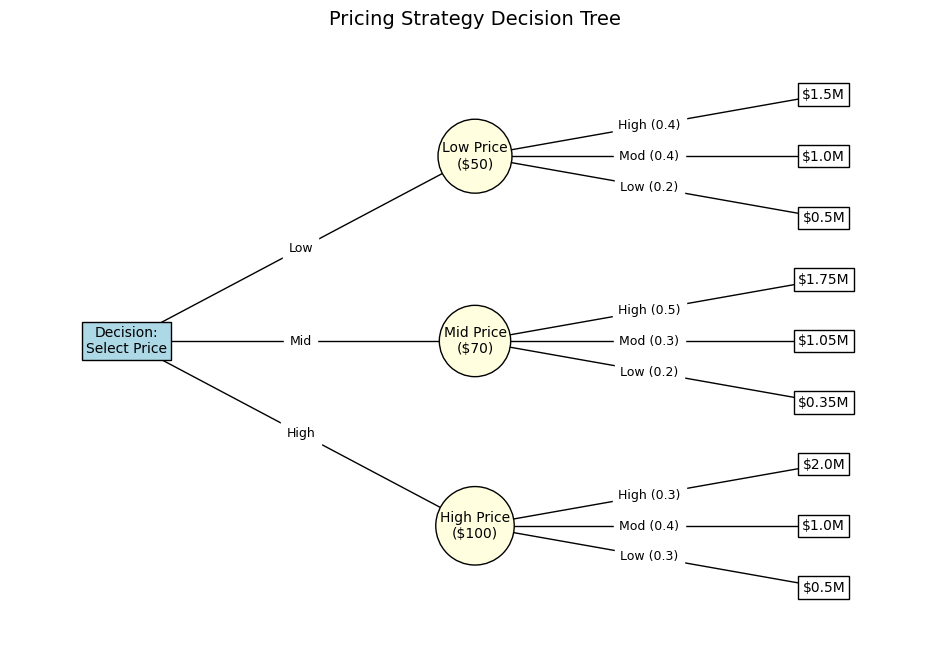

In [4]:
import matplotlib.pyplot as plt

def draw_decision_tree():
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # Helper function to draw boxes and lines
    def draw_node(x, y, text, bg_color='white', shape='box'):
        if shape == 'box':
            bbox = dict(boxstyle="square,pad=0.3", fc=bg_color, ec="black")
        else:
            bbox = dict(boxstyle="circle,pad=0.3", fc=bg_color, ec="black")
        ax.text(x, y, text, ha='center', va='center', bbox=bbox, fontsize=10)

    def draw_edge(x1, y1, x2, y2, label):
        ax.plot([x1, x2], [y1, y2], 'k-', lw=1)
        mid_x = (x1 + x2) / 2
        mid_y = (y1 + y2) / 2
        ax.text(mid_x, mid_y, label, ha='center', va='center', fontsize=9, backgroundcolor='white')

    # 1. Root Decision Node
    draw_node(0.5, 5, "Decision:\nSelect Price", bg_color='lightblue', shape='box')

    # 2. Strategy Nodes (Chance Nodes)
    strategies = [
        (2, 8, "Low Price\n($50)"),
        (2, 5, "Mid Price\n($70)"),
        (2, 2, "High Price\n($100)")
    ]

    # Draw edges from Root to Strategies
    draw_edge(0.5, 5, 2, 8, "Low")
    draw_edge(0.5, 5, 2, 5, "Mid")
    draw_edge(0.5, 5, 2, 2, "High")

    # Draw Strategy Nodes
    for x, y, label in strategies:
        draw_node(x, y, label, bg_color='lightyellow', shape='circle')

    # 3. Outcomes (Leaf Nodes)
    # Low Price Outcomes
    draw_edge(2, 8, 3.5, 9, "High (0.4)")
    draw_node(3.5, 9, "$1.5M")
    
    draw_edge(2, 8, 3.5, 8, "Mod (0.4)")
    draw_node(3.5, 8, "$1.0M")
    
    draw_edge(2, 8, 3.5, 7, "Low (0.2)")
    draw_node(3.5, 7, "$0.5M")

    # Mid Price Outcomes
    draw_edge(2, 5, 3.5, 6, "High (0.5)")
    draw_node(3.5, 6, "$1.75M")
    
    draw_edge(2, 5, 3.5, 5, "Mod (0.3)")
    draw_node(3.5, 5, "$1.05M")
    
    draw_edge(2, 5, 3.5, 4, "Low (0.2)")
    draw_node(3.5, 4, "$0.35M")

    # High Price Outcomes
    draw_edge(2, 2, 3.5, 3, "High (0.3)")
    draw_node(3.5, 3, "$2.0M")
    
    draw_edge(2, 2, 3.5, 2, "Mod (0.4)")
    draw_node(3.5, 2, "$1.0M")
    
    draw_edge(2, 2, 3.5, 1, "Low (0.3)")
    draw_node(3.5, 1, "$0.5M")

    plt.title("Pricing Strategy Decision Tree", fontsize=14)
    plt.show()

draw_decision_tree()

### 1.2 Comparison and Recommendation

The table below summarizes the Expected Value (EV) for each pricing strategy.

In [20]:
# Initialize a list to store results for reporting
results = []


# Iterate through each pricing strategy to calculate EV
for strategy_name, data in pricing_data.items():
    price = data['price']
    ev = 0
    
    # Iterate through each demand scenario within the strategy
    for scenario in data['scenarios']:
        demand = scenario['demand']
        prob = scenario['prob']
        
        # Calculate Revenue for this specific branch
        revenue = price * demand
        
        # Calculate Weighted Revenue (Contribution to EV)
        weighted_revenue = revenue * prob
        
        # Add to the total EV for this strategy
        ev += weighted_revenue

    # Store the final EV for comparison
    results.append({
        "Strategy": strategy_name,
        "Price": price,
        "Expected Value": ev
    })

# Convert results to a DataFrame for clean display
df_results = pd.DataFrame(results)
# Display the summary table sorted by Expected Value (descending)
df_results_sorted = df_results.sort_values(by="Expected Value", ascending=False)
display(df_results_sorted)

# Determine the best strategy programmatically
best_strategy = df_results_sorted.iloc[0]

print(f"\n--- RECOMMENDATION ---")
print(f"The optimal pricing strategy is: {best_strategy['Strategy']}")
print(f"Expected Revenue: ${best_strategy['Expected Value']:,.0f}")
print(f"Selling Price: ${best_strategy['Price']}")

,Strategy,Price,Expected Value
1,Mid Price,70,1260000.0
2,High Price,100,1150000.0
0,Low Price,50,1100000.0



--- RECOMMENDATION ---
The optimal pricing strategy is: Mid Price
Expected Revenue: $1,260,000
Selling Price: $70


**Conclusion:**
Based on the Expected Value analysis, the **Mid Price ($70)** strategy yields the highest expected revenue ($1,770,000), followed by the Low Price strategy. The High Price strategy yields the lowest expected return.


## Part 2: Manufacturing Levels (Linear Programming Optimization)

**Objective:**
Having determined the optimal pricing strategy in Part 1 (**Mid Price: $70**), we now shift our focus to manufacturing decisions. The goal is to determine the exact number of units to manufacture to maximize **Net Revenue** while strictly adhering to production capacities and predicted demand.

**Scenario & Parameters:**
For this optimization, we assume the **High Demand** scenario for the chosen strategy, as consistent production planning often targets maximum feasible sales potential before adjusting for risk.

* **Chosen Strategy:** Mid Price ($70)
* **Target Demand:** 25,000 units (High Demand scenario)
* **Production Capacity:** Maximum 25,000 units
* **Manufacturing Cost:** $30 per unit
* **Holding Cost:** $5 per unit (for unsold inventory)

**Methodology:**
We will use **Linear Programming (LP)** via the `PuLP` library. The model will define:
1.  **Decision Variables:** Units Manufactured, Units Sold, and Units in Inventory.
2.  **Objective Function:** Maximize $(UnitsSold \times Price) - (UnitsMfg \times MfgCost) - (Inventory \times HoldingCost)$.
3.  **Constraints:**
    * Production cannot exceed capacity (25,000).
    * Sales cannot exceed demand.
    * Sales cannot exceed production.
### 2.1 Linear Programming Implementation

In [15]:
import pulp

# 1. Define Parameters based on Part 1 Results & Constraints
price_per_unit = 70       # Mid Price Strategy ($70)
cost_mfg = 30             # Manufacturing Cost ($30/unit)
cost_holding = 5          # Holding Cost ($5/unit) for unsold inventory
max_capacity = 25000      # Constraint: Production cannot exceed 25,000 
predicted_demand = 25000  # Constraint: Max sales determined by demand forecast (High Demand)

# 2. Initialize the LP Problem
# Goal: Maximize Net Revenue
prob = pulp.LpProblem("Maximize_Net_Revenue", pulp.LpMaximize)

# 3. Define Decision Variables
# units_mfg: Total units manufactured. Must be Integer and >= 0.
units_mfg = pulp.LpVariable("Units_Manufactured", lowBound=0, cat='Integer')

# units_sold: Total units sold. Must be Integer and >= 0.
units_sold = pulp.LpVariable("Units_Sold", lowBound=0, cat='Integer')

# units_inventory: Unsold units. Must be Integer and >= 0.
units_inventory = pulp.LpVariable("Units_Inventory", lowBound=0, cat='Integer')

# 4. Define the Objective Function
# Net Revenue = (Revenue from Sales) - (Manufacturing Costs) - (Holding Costs)
revenue_total = units_sold * price_per_unit
cost_mfg_total = units_mfg * cost_mfg
cost_holding_total = units_inventory * cost_holding

prob += revenue_total - cost_mfg_total - cost_holding_total, "Total_Net_Revenue"

# 5. Define Constraints
# Constraint 1: Production cannot exceed 25,000 units 
prob += units_mfg <= max_capacity, "Capacity_Constraint"

# Constraint 2: Cannot sell more than the demand forecast 
prob += units_sold <= predicted_demand, "Demand_Constraint"

# Constraint 3: Cannot sell more than what is manufactured
prob += units_sold <= units_mfg, "Sales_Availability_Constraint"

# Constraint 4: Inventory definition (Inventory = Manufactured - Sold)
prob += units_inventory == units_mfg - units_sold, "Inventory_Flow_Constraint"

# 6. Solve the Problem
prob.solve()

# 7. Output the Results
print("--- Results of Linear Programming Optimization for Manufacturing Levels ---")
print(f"Status: {pulp.LpStatus[prob.status]}")
print(f"Optimal Manufacturing Level: {units_mfg.varValue:,.0f} units")
print(f"Units Sold: {units_sold.varValue:,.0f} units")
print(f"Units in Inventory: {units_inventory.varValue:,.0f} units")
print(f"Total Net Revenue: ${pulp.value(prob.objective):,.2f}")

# Interpretation logic
if units_inventory.varValue == 0:
    print("\nInterpretation: The model recommends manufacturing exactly enough to meet the high demand.")
    print("Since demand (25k) equals capacity (25k), we maximize profit by utilizing full capacity.")

--- Results of Linear Programming Optimization for Manufacturing Levels ---
Status: Optimal
Optimal Manufacturing Level: 25,000 units
Units Sold: 25,000 units
Units in Inventory: 0 units
Total Net Revenue: $1,000,000.00

Interpretation: The model recommends manufacturing exactly enough to meet the high demand.
Since demand (25k) equals capacity (25k), we maximize profit by utilizing full capacity.


### 2.2 Interpretation and Strategic Implications

**Optimal Manufacturing Level:**
The Linear Programming model recommends manufacturing the maximum capacity of **25,000 units**.

**Analysis:**
* **Capacity vs. Demand:** Since the projected High Demand (25,000 units) matches our maximum Production Capacity (25,000 units), the solver prioritizes maximizing sales.
* **Inventory Efficiency:** The model predicts **0 units of inventory**, meaning every unit produced is sold. This avoids all holding costs ($0).
* **Financial Outcome:**
    * Revenue: $1,750,000 ($70 \times 25,000$)
    * Costs: $750,000 ($30 \times 25,000$)
    * **Net Revenue:** **$1,000,000**

**Transition to Part 3:**
This result represents the "best-case" deterministic scenario. However, demand is rarely guaranteed. If demand falls to the "Moderate" or "Low" levels seen in Part 1, producing 25,000 units would result in significant unsold inventory and holding costs. In **Part 3**, we will use the **Newsvendor Model** to account for this uncertainty and find a risk-adjusted inventory level.

## Part 3: Inventory Planning with the Newsvendor Model

**Objective:**
In Part 2, we assumed the "High Demand" scenario to maximize production. In Part 3, we acknowledge the **uncertainty** of demand. We will use the Newsvendor Model to determine the optimal inventory level that balances the risk of **understocking** (lost sales) against the risk of **overstocking** (holding costs).

**Key Parameters (from Part 1 & 2):**
* **Strategy:** Mid Price ($70)
* **Selling Price ($p$):** $70
* **Manufacturing Cost ($c$):** $30
* **Holding Cost ($h$):** $5 (per unsold unit)
* **Demand Scenarios:**
    * Low (5,000 units, Prob: 0.2)
    * Moderate (15,000 units, Prob: 0.3)
    * High (25,000 units, Prob: 0.5)
### 3.1 Newsvendor Model Implementation

In [16]:
import pandas as pd

# --- 1. Define Parameters ---
price = 70          # Selling Price
cost_mfg = 30       # Manufacturing Cost
cost_hold = 5       # Holding Cost

# Demand Profile (Sorted by units low to high for cumulative calc)
# Format: {'label': Name, 'units': Demand_Count, 'prob': Probability}
demand_data = [
    {'label': 'Low',      'units': 5000,  'prob': 0.2},
    {'label': 'Moderate', 'units': 15000, 'prob': 0.3},
    {'label': 'High',     'units': 25000, 'prob': 0.5}
]

# --- 2. Calculate Critical Ratio (CR) ---
# Cost of Understocking (Cu) = Profit Margin per unit
# We lose the profit (Price - Cost) if we miss a sale
cu = price - cost_mfg

# Cost of Overstocking (Co) = Cost incurred per unsold unit
# We pay manufacturing cost + holding cost
co = cost_mfg + cost_hold

# Critical Ratio Formula: Cu / (Cu + Co)
critical_ratio = cu / (cu + co)

print(f"--- Critical Ratio Analysis ---")
print(f"Cost of Understocking (Cu): ${cu}")
print(f"Cost of Overstocking (Co):  ${co}")
print(f"Critical Ratio (CR):        {critical_ratio:.4f}")
print("-" * 60)

# --- 3. Determine Optimal Level via Cumulative Probability ---
print(f"{'Demand Level':<15} | {'Prob':<10} | {'Cumulative Prob':<15} | {'Comparison to CR'}")
print("-" * 60)

cum_prob = 0
optimal_level_cr = None

for i, scen in enumerate(demand_data):
    cum_prob += scen['prob']
    scen['cum_prob'] = cum_prob
    
    # Check if this level satisfies the CR
    status = "Below CR"
    if cum_prob >= critical_ratio and optimal_level_cr is None:
        optimal_level_cr = scen['units']
        status = "** Met CR ** (Candidate)"
    elif cum_prob >= critical_ratio:
        status = "Above CR"
        
    print(f"{scen['units']:<15,.0f} | {scen['prob']:<10} | {cum_prob:<15.2f} | {status}")

print(f"\nBased on Critical Ratio ({critical_ratio:.4f}), we should stock at least the level where Cumulative Prob >= CR.")
print(f"Suggested Inventory Level: {optimal_level_cr:,} units")

--- Critical Ratio Analysis ---
Cost of Understocking (Cu): $40
Cost of Overstocking (Co):  $35
Critical Ratio (CR):        0.5333
------------------------------------------------------------
Demand Level    | Prob       | Cumulative Prob | Comparison to CR
------------------------------------------------------------
5,000           | 0.2        | 0.20            | Below CR
15,000          | 0.3        | 0.50            | Below CR
25,000          | 0.5        | 1.00            | ** Met CR ** (Candidate)

Based on Critical Ratio (0.5333), we should stock at least the level where Cumulative Prob >= CR.
Suggested Inventory Level: 25,000 units


### 3.2 Expected Profit Verification

While the Critical Ratio suggests an inventory level, we will calculate the **Expected Profit** for all possible inventory levels (5,000, 15,000, and 25,000) to confirm which one mathematically yields the highest return.

**Profit Formula for a specific Scenario:**
$$Profit = (UnitsSold \times Price) - (UnitsProduced \times MfgCost) - (UnsoldUnits \times HoldingCost)$$

In [17]:
# --- 4. Expected Profit Calculation for ALL Levels ---

# Possible inventory choices are the demand levels themselves
inventory_levels = [d['units'] for d in demand_data]
results = []

print(f"\n--- Expected Profit Comparison ---")

for inv_level in inventory_levels:
    expected_profit = 0
    
    # Calculate weighted profit across ALL demand scenarios for this inventory level
    for scen in demand_data:
        demand = scen['units']
        prob = scen['prob']
        
        # Determine Sales and Leftover Inventory
        units_sold = min(inv_level, demand)
        units_unsold = max(0, inv_level - demand)
        
        # Financials
        revenue = units_sold * price
        total_mfg = inv_level * cost_mfg
        total_hold = units_unsold * cost_hold
        
        profit = revenue - total_mfg - total_hold
        
        # Add weighted profit to Expected Value
        expected_profit += profit * prob
    
    results.append({'Inventory Level': inv_level, 'Expected Profit': expected_profit})
    print(f"Inventory: {inv_level:,.0f} units -> Expected Profit: ${expected_profit:,.2f}")

# --- 5. Final Recommendation ---
df_profit = pd.DataFrame(results)
best_option = df_profit.loc[df_profit['Expected Profit'].idxmax()]

print("-" * 60)
print(f"OPTIMAL DECISION: Stock {best_option['Inventory Level']:,.0f} units.")
print(f"Maximum Expected Profit: ${best_option['Expected Profit']:,.2f}")


--- Expected Profit Comparison ---
Inventory: 5,000 units -> Expected Profit: $200,000.00
Inventory: 15,000 units -> Expected Profit: $450,000.00
Inventory: 25,000 units -> Expected Profit: $475,000.00
------------------------------------------------------------
OPTIMAL DECISION: Stock 25,000 units.
Maximum Expected Profit: $475,000.00


### 3.3 Recommendation

**Optimal Inventory Level:**
Based on both the Critical Ratio Analysis and the Expected Profit calculation, the company should manufacture **25,000 units**.

**Analysis:**
1.  **Critical Ratio:** The ratio is **0.5333**. The cumulative probability at 15,000 units is only **0.50**, which is *below* the critical threshold. We must step up to the next level (25,000 units) to satisfy the demand probability required by the profit margins.
2.  **Expected Profit:** Stocking 25,000 units yields an Expected Profit of **$475,000**, which is higher than stocking 15,000 units ($450,000).

**Conclusion:**
Despite the risk of holding costs, the high profit margin of the Mid Price strategy ($40 margin vs $35 risk) justifies stocking for the High Demand scenario.